# Cold start on the IDAES CSTR

The saponification CSTR carries a full algebraic layer: the outlet
stream, the reaction-rate cascade, and the packed holdup's water member.
`drto.cold_start_dynamic` seeds the states on straight lines to their
declared targets and solves that algebra pointwise, so the guess is
consistent everywhere except the declared dynamics.

The plots show the model before the initialization and after it; the
report shows the per-point solves working through the algebra.

In [1]:
%matplotlib inline
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import drto
import pyomo_pounce
from drto import plot_controls, plot_stage_cost, plot_states
from idaes.core import FlowsheetBlock
from idaes.models.unit_models import CSTR
from idaes.models.properties.examples.saponification_thermo import (
    SaponificationParameterBlock,
)
from idaes.models.properties.examples.saponification_reactions import (
    SaponificationReactionParameterBlock,
)
from idaes.core.util.model_statistics import degrees_of_freedom

F_IN, C_NAOH, C_EA = 1.0, 100.0, 100.0     # m3/s, mol/m3, mol/m3
T_IN, P_IN, VOLUME = 303.15, 101325.0, 1.0  # K, Pa, m3
T_START = 318.0                             # K, the perturbed start
DC_START = 20.0                             # mol/m3, conversion knocked back


def feed(blk, t):
    # the flow is a manipulated variable: initialized, not fixed
    blk.inlet.flow_vol[t].set_value(F_IN)
    blk.inlet.conc_mol_comp[t, "H2O"].fix(55388.0)
    blk.inlet.conc_mol_comp[t, "NaOH"].fix(C_NAOH)
    blk.inlet.conc_mol_comp[t, "EthylAcetate"].fix(C_EA)
    blk.inlet.conc_mol_comp[t, "SodiumAcetate"].fix(0.0)
    blk.inlet.conc_mol_comp[t, "Ethanol"].fix(0.0)
    blk.inlet.temperature[t].fix(T_IN)
    blk.inlet.pressure[t].fix(P_IN)


def cstr(m):
    m.fs.props = SaponificationParameterBlock()
    m.fs.rxn = SaponificationReactionParameterBlock(property_package=m.fs.props)
    m.fs.cstr = CSTR(property_package=m.fs.props, reaction_package=m.fs.rxn,
                     has_equilibrium_reactions=False, has_heat_of_reaction=True,
                     has_heat_transfer=True)
    return m

In [2]:
def build(N=10, h=1, ncp=3):
    samples = [i * h for i in range(N + 1)]
    m = pyo.ConcreteModel()
    m.fs = FlowsheetBlock(dynamic=True, time_set=samples, time_units=pyo.units.s)
    cstr(m)

    drto.horizon(m.fs.time)             # before discretization: it takes the grid
    pyo.TransformationFactory("dae.collocation").apply_to(
        m, wrt=m.fs.time, nfe=N, ncp=ncp, scheme="LAGRANGE-RADAU")
    for t in m.fs.time:
        feed(m.fs.cstr, t)
        m.fs.cstr.volume[t].fix(VOLUME)

    cv, t0 = m.fs.cstr.control_volume, m.fs.time.first()
    fin = m.fs.cstr.inlet.flow_vol
    es = list(cv.energy_holdup.index_set().subsets())[1]
    U = pyo.units

    # targets and feedback Params declared in the owners' units, so the
    # registry reads back with the physics visible and the equations that
    # use them stay dimensionally consistent; filled after the steady solve
    m.eng_ss = pyo.Param(es, initialize=0.0, mutable=True, units=U.J)
    m.duty_ss = pyo.Param(initialize=0.0, mutable=True, units=U.W)
    m.flow_ss = pyo.Param(initialize=F_IN, mutable=True, units=U.m**3 / U.s)

    # the initial condition pins the true states: the four reacting species
    # and the energy. The water holdup is algebraic, its concentration fixed
    # by the property package, so it carries no initial condition. The
    # energy holdup is closed-form in T with this constant-property package.
    comps = ["NaOH", "EthylAcetate", "SodiumAcetate", "Ethanol"]
    props = m.fs.props
    e0 = VOLUME * pyo.value(
        props.dens_mol * props.cp_mol * (T_START * U.K - props.temperature_ref))
    m.mat0 = pyo.Param(comps, initialize=0.0, mutable=True, units=U.mol)
    m.eng0 = pyo.Param(es, initialize=e0, mutable=True, units=U.J)

    @m.Constraint(comps)
    def ic_mat(mm, j):
        return cv.material_holdup[t0, "Liq", j] == mm.mat0[j]

    @m.Constraint(es)
    def ic_eng(mm, p):
        return cv.energy_holdup[t0, p] == mm.eng0[p]

    # unit-carrying scales make the cost dimensionless, so it renders with
    # clean units instead of (inc): each term is (quantity/scale)**2
    m.scale_E = pyo.Param(initialize=1.0e6, units=U.J, mutable=True)
    m.scale_Q = pyo.Param(initialize=1.0e6, units=U.W, mutable=True)
    m.scale_F = pyo.Param(initialize=0.1, units=U.m**3 / U.s, mutable=True)
    stages = samples[:-1]
    m.cost = pyo.Var(stages, initialize=0.0)
    m.term = pyo.Var(initialize=0.0)

    @m.Constraint(stages)
    def stage(mm, t):
        return mm.cost[t] == (
            ((cv.energy_holdup[t, "Liq"] - mm.eng_ss["Liq"]) / mm.scale_E) ** 2
            + ((cv.heat[t] - mm.duty_ss) / mm.scale_Q) ** 2
            + ((fin[t] - mm.flow_ss) / mm.scale_F) ** 2)

    tN = m.fs.time.last()

    @m.Constraint()  # the stage cost with the controls removed, at tN
    def terminal(mm):
        return mm.term == (
            (cv.energy_holdup[tN, "Liq"] - mm.eng_ss["Liq"]) / mm.scale_E) ** 2

    drto.state(cv.material_holdup[:, "Liq", "NaOH"],
               cv.material_holdup[:, "Liq", "EthylAcetate"],
               cv.material_holdup[:, "Liq", "SodiumAcetate"],
               cv.material_holdup[:, "Liq", "Ethanol"],
               cv.energy_holdup)
    drto.dynamics(cv.material_balances, cv.enthalpy_balances)
    drto.control(cv.heat, fin, profile="piecewise_constant")
    drto.tracking_stage_cost(m.stage)
    drto.tracking_terminal_cost(m.terminal)
    drto.initial_condition(m.ic_mat, m.ic_eng)
    m.ss_naoh = drto.steady_state(cv.material_holdup[:, "Liq", "NaOH"],
        pyo.Param(initialize=0.0, mutable=True, units=U.mol))
    m.ss_ea = drto.steady_state(cv.material_holdup[:, "Liq", "EthylAcetate"],
        pyo.Param(initialize=0.0, mutable=True, units=U.mol))
    m.ss_sa = drto.steady_state(cv.material_holdup[:, "Liq", "SodiumAcetate"],
        pyo.Param(initialize=0.0, mutable=True, units=U.mol))
    m.ss_etoh = drto.steady_state(cv.material_holdup[:, "Liq", "Ethanol"],
        pyo.Param(initialize=0.0, mutable=True, units=U.mol))
    drto.steady_state(cv.energy_holdup, m.eng_ss)
    drto.steady_state_control(cv.heat, m.duty_ss)
    drto.steady_state_control(fin, m.flow_ss)
    return m


m = build()
drto.info(m)

horizon,"fs._time (ContinuousSet, 31 points)"
states,"fs.cstr.control_volume.material_holdup_Liq_NaOH (free, mol), fs.cstr.control_volume.material_holdup_Liq_EthylAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_Ethanol (free, mol), fs.cstr.control_volume.energy_holdup (free, J)"
dynamics,"fs.cstr.control_volume.material_accumulation[t,p,j] == fs.cstr.control_volume.properties_in[t].flow_vol*fs.cstr.control_volume.properties_in[t].conc_mol_comp[j] - fs.cstr.control_volume.properties_out[t].flow_vol*fs.cstr.control_volume.properties_out[t].conc_mol_comp[j] + fs.cstr.control_volume.rate_reaction_generation[t,p,j] for t in fs.cstr.control_volume.SetProduct_OrderedSet (mol/s)"
dynamics,"fs.cstr.control_volume.energy_accumulation[t,Liq] == fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_in[t].flow_vol*(fs.cstr.control_volume.properties_in[t].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[t].flow_vol*(fs.cstr.control_volume.properties_out[t].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat[t] + (- fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[t,R1]) for t in fs._time (W)"
controls,"fs.cstr.control_volume.heat (piecewise_constant, free, W), fs.cstr._flow_vol_inlet_ref (piecewise_constant, free, m**3/s)"
tracking stage cost,"cost[t] == ((fs.cstr.control_volume.energy_holdup[t,'Liq'] - eng_ss[Liq])/scale_E)**2 + ((fs.cstr.control_volume.heat[t] - duty_ss)/scale_Q)**2 + ((fs.cstr._flow_vol_inlet_ref[t] - flow_ss)/scale_F)**2 for t in sorted(fs._time)[:-1]"
terminal cost,"term == ((fs.cstr.control_volume.energy_holdup[10.0,Liq] - eng_ss[Liq])/scale_E)**2"
initial conditions,"mat0[j] == fs.cstr.control_volume.material_holdup[0.0,'Liq',j] for j in OrderedScalarSet (mol)"
initial conditions,"eng0[p] == fs.cstr.control_volume.energy_holdup[0.0,p] for p in fs.props.phase_list (J)"
steady-state targets,"ss_naoh (of fs.cstr.control_volume.material_holdup_Liq_NaOH, mol), ss_ea (of fs.cstr.control_volume.material_holdup_Liq_EthylAcetate, mol), ss_sa (of fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate, mol), ss_etoh (of fs.cstr.control_volume.material_holdup_Liq_Ethanol, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)"
steady-state control targets,"duty_ss (of fs.cstr.control_volume.heat, W), flow_ss (of fs.cstr._flow_vol_inlet_ref, m**3/s)"


## The setpoint and the start

The steady solve fills the targets, and the initial condition is the
setpoint composition knocked back along the reaction, hot.

In [3]:
U = pyo.units
_cache = {}


def scale_factor(u):
    s = str(u)
    if s not in _cache:
        _cache[s] = 1.0
        for target, sf in ((U.J, 1e-7), (U.W, 1e-6), (U.J / U.s, 1e-6)):
            try:
                U.convert_value(1.0, from_units=u, to_units=target)
                _cache[s] = sf
                break
            except Exception:  # incompatible units: unscaled
                pass
    return _cache[s]


def tag_scaling(model):
    """Tag every Var and active row with its units-driven factor."""
    if model.component("scaling_factor") is not None:
        model.del_component("scaling_factor")
    model.scaling_factor = pyo.Suffix(direction=pyo.Suffix.EXPORT)
    for v in model.component_data_objects(pyo.Var, descend_into=True):
        # the pin slacks enter the objective linearly with weight mu, so
        # scaling them blows the objective's gradients; near zero anyway,
        # they stay unscaled
        if v.parent_component().local_name.endswith(("_pin_up", "_pin_lo")):
            continue
        f = scale_factor(U.get_units(v))
        if f != 1.0:
            model.scaling_factor[v] = f
    for c in model.component_data_objects(pyo.Constraint, active=True,
                                          descend_into=True):
        try:
            f = scale_factor(U.get_units(c.body))
        except Exception:  # a unitless or inconsistent row: unscaled
            f = 1.0
        if f != 1.0:
            model.scaling_factor[c] = f


def scaled_solve(model, tee=False):
    """Retag by units, solve the scaled clone, map the solution back."""
    tag_scaling(model)
    sm = pyo.TransformationFactory("core.scale_model").create_using(model)
    res = pyo.SolverFactory("pounce").solve(sm, tee=tee)
    pyo.TransformationFactory("core.scale_model").propagate_solution(sm, model)
    return res

In [4]:
def plot_rates(m):
    """The undeclared algebraic pair: the rate constant and the rate."""
    rxn = m.fs.cstr.control_volume.reactions
    grid = sorted(m.fs.time)
    fig, axes = plt.subplots(1, 2, figsize=(9, 3), constrained_layout=True)
    for ax, name, vals in (
        (axes[0], "k_rxn [m3/mol/s]",
         [pyo.value(rxn[t].k_rxn) for t in grid]),
        (axes[1], "reaction_rate[R1] [mol/m3/s]",
         [pyo.value(rxn[t].reaction_rate["R1"]) for t in grid]),
    ):
        ax.plot(grid, vals, ".-")
        ax.set_title(name)
        ax.set_xlabel("time [s]")

In [5]:
ss = pyo.TransformationFactory("drto.steady_state_simulation").create_using(
    m, controls={m.fs.cstr.control_volume.heat.name: 0.0,
                 m.fs.cstr.inlet.flow_vol.name: F_IN})
assert degrees_of_freedom(ss) == 0
scaled_solve(ss, tee=True)

cvs = ss.fs.cstr.control_volume
print(f"setpoint  T = {pyo.value(cvs.properties_out[0.0].temperature):7.3f} K"
      f"   NaOH = {pyo.value(cvs.properties_out[0.0].conc_mol_comp['NaOH']):6.3f} mol/m3")

for j, ssp in (("NaOH", m.ss_naoh), ("EthylAcetate", m.ss_ea),
               ("SodiumAcetate", m.ss_sa), ("Ethanol", m.ss_etoh)):
    ssp.set_value(pyo.value(cvs.material_holdup["Liq", j]))
# the start: the setpoint composition with conversion knocked back by
# DC_START along the reaction stoichiometry, hot by T_START - T_ss
for j, sgn in (("NaOH", 1), ("EthylAcetate", 1),
               ("SodiumAcetate", -1), ("Ethanol", -1)):
    m.mat0[j] = pyo.value(cvs.material_holdup["Liq", j]) + sgn * DC_START * VOLUME
for k in m.eng_ss:
    m.eng_ss[k] = pyo.value(cvs.energy_holdup[k])
drto.info(ss)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpev60n4i1.pyomo.nl...
Parsed 22 vars, 2

   8  0.0000000e+00 5.36e-13 1.50e-09   -3.8 2.16e-08      - 1.00e+00 1.00e+00t  0
   9  0.0000000e+00 5.36e-13 1.84e-11   -5.7 2.23e-08      - 1.00e+00 1.00e+00t  0
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  10  0.0000000e+00 5.36e-13 2.51e-14   -8.6 2.23e-08      - 1.00e+00 1.00e+00T  0


Number of Iterations....: 10

                                   (scaled)                 (unscaled)
Objective...............:   0.0000000000000000e+00    0.0000000000000000e+00
Dual infeasibility......:   2.5059036119794365e-14    2.5059036119794365e-14
Constraint violation....:   5.3572882813901190e-13    2.2351741790771484e-08
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5059035596953245e-09    2.5059035596953245e-09
Overall NLP error.......:   2.5059035596953245e-09    2.2351741790771484e-08


Number of objective function evaluations             = 11
Number of objective gradient evaluations   

setpoint  T = 304.039 K   NaOH = 24.286 mol/m3


states,"fs.cstr.control_volume.material_holdup_Liq_NaOH (free), fs.cstr.control_volume.material_holdup_Liq_EthylAcetate (free), fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate (free), fs.cstr.control_volume.material_holdup_Liq_Ethanol (free), fs.cstr.control_volume.energy_holdup (free)"
dynamics,"fs.cstr.control_volume.material_accumulation[o,_r] == fs.cstr.control_volume.properties_in[0.0].flow_vol*fs.cstr.control_volume.properties_in[0.0].conc_mol_comp[_r] - fs.cstr.control_volume.properties_out[0.0].flow_vol*fs.cstr.control_volume.properties_out[0.0].conc_mol_comp[_r] + fs.cstr.control_volume.rate_reaction_generation[o,_r] for o in fs.props._phase_component_set (inc)"
dynamics,fs.cstr.control_volume.energy_accumulation[Liq] == fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_in[0.0].flow_vol*(fs.cstr.control_volume.properties_in[0.0].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[0.0].flow_vol*(fs.cstr.control_volume.properties_out[0.0].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat - fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[R1] (inc)
controls,"fs.cstr.control_volume.heat (fixed), fs.cstr._flow_vol_inlet_ref (fixed, m**3/s)"
steady-state targets,"ss_naoh (of fs.cstr.control_volume.material_holdup_Liq_NaOH, mol), ss_ea (of fs.cstr.control_volume.material_holdup_Liq_EthylAcetate, mol), ss_sa (of fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate, mol), ss_etoh (of fs.cstr.control_volume.material_holdup_Liq_Ethanol, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)"
steady-state control targets,"duty_ss (of fs.cstr.control_volume.heat, W), flow_ss (of fs.cstr._flow_vol_inlet_ref, m**3/s)"


## The controller model

The terminal segment joins at definition time: the infinite-horizon
transformation applies before any plot or initialization, so the cold
start also covers the tail. The steady reduction above branches from
the plain declarations, which is why it runs first.

In [6]:
pyo.TransformationFactory("drto.infinite_horizon").apply_to(m)
drto.info(m)

horizon,"fs._time (ContinuousSet, 31 points)"
states,"fs.cstr.control_volume.material_holdup_Liq_NaOH (free, mol), fs.cstr.control_volume.material_holdup_Liq_EthylAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_Ethanol (free, mol), fs.cstr.control_volume.energy_holdup (free, J)"
dynamics,"fs.cstr.control_volume.material_accumulation[t,p,j] == fs.cstr.control_volume.properties_in[t].flow_vol*fs.cstr.control_volume.properties_in[t].conc_mol_comp[j] - fs.cstr.control_volume.properties_out[t].flow_vol*fs.cstr.control_volume.properties_out[t].conc_mol_comp[j] + fs.cstr.control_volume.rate_reaction_generation[t,p,j] for t in fs.cstr.control_volume.SetProduct_OrderedSet (mol/s)"
dynamics,"fs.cstr.control_volume.energy_accumulation[t,Liq] == fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_in[t].flow_vol*(fs.cstr.control_volume.properties_in[t].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[t].flow_vol*(fs.cstr.control_volume.properties_out[t].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat[t] + (- fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[t,R1]) for t in fs._time (W)"
controls,"fs.cstr.control_volume.heat (piecewise_constant, free, W), fs.cstr._flow_vol_inlet_ref (piecewise_constant, free, m**3/s)"
tracking stage cost,"cost[t] == ((fs.cstr.control_volume.energy_holdup[t,'Liq'] - eng_ss[Liq])/scale_E)**2 + ((fs.cstr.control_volume.heat[t] - duty_ss)/scale_Q)**2 + ((fs.cstr._flow_vol_inlet_ref[t] - flow_ss)/scale_F)**2 for t in sorted(fs._time)[:-1]"
terminal cost,"term == ((fs.cstr.control_volume.energy_holdup[10.0,Liq] - eng_ss[Liq])/scale_E)**2"
initial conditions,"mat0[j] == fs.cstr.control_volume.material_holdup[0.0,'Liq',j] for j in OrderedScalarSet (mol)"
initial conditions,"eng0[p] == fs.cstr.control_volume.energy_holdup[0.0,p] for p in fs.props.phase_list (J)"
steady-state targets,"ss_naoh (of fs.cstr.control_volume.material_holdup_Liq_NaOH, mol), ss_ea (of fs.cstr.control_volume.material_holdup_Liq_EthylAcetate, mol), ss_sa (of fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate, mol), ss_etoh (of fs.cstr.control_volume.material_holdup_Liq_Ethanol, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)"
steady-state control targets,"duty_ss (of fs.cstr.control_volume.heat, W), flow_ss (of fs.cstr._flow_vol_inlet_ref, m**3/s)"


## Before

The builder's values: flat, and unaware of the initial condition. The
rate constant and the reaction rate sit at the property package's
defaults.

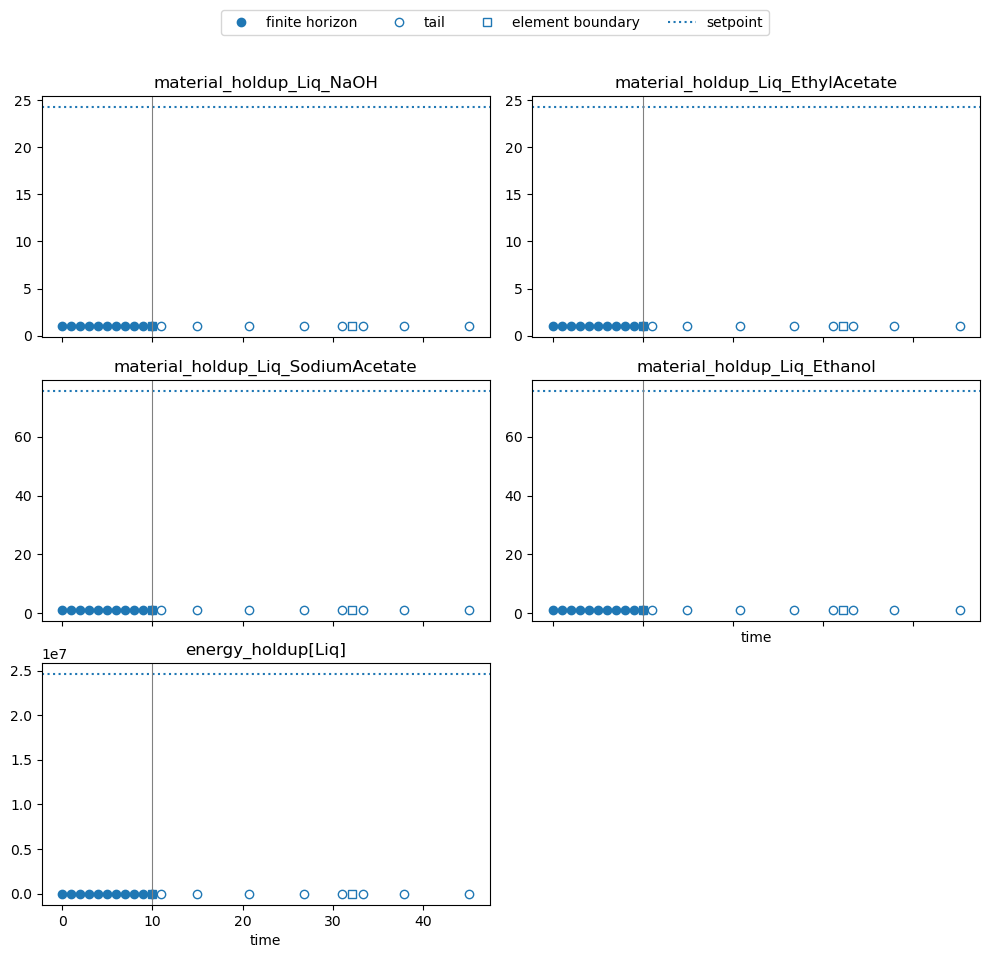

In [7]:
plot_states(m);
plt.show()

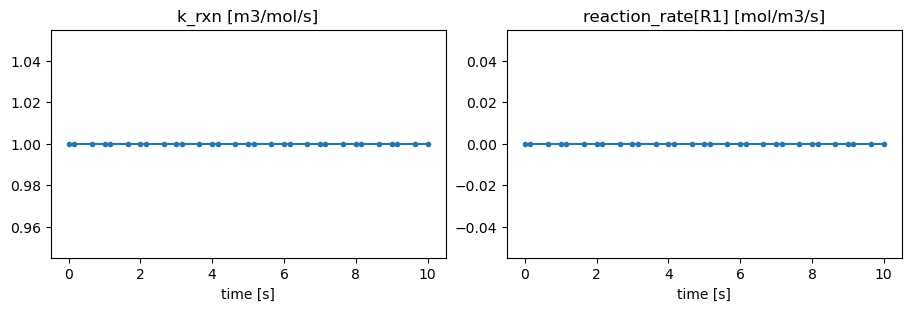

In [8]:
plot_rates(m)
plt.show()

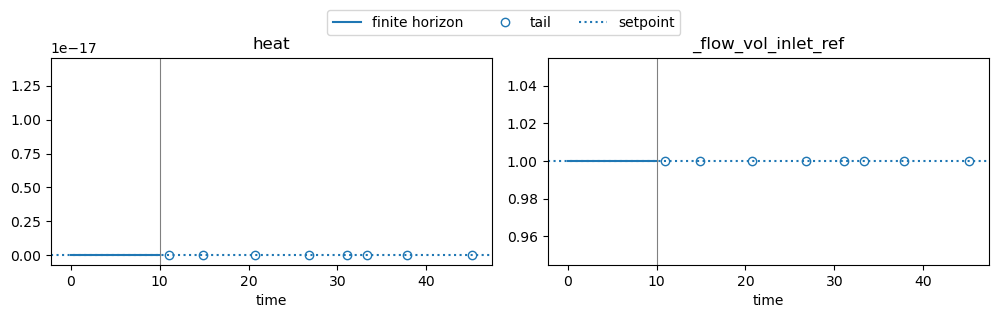

In [9]:
plot_controls(m)
plt.show()

## The cold start

States on their lines, controls at their targets, the tail at rest on
the targets with the pin slacks at zero, and one block solve working
the outlet stream, the reaction cascade, and the water member
consistent at every grid point, the segment's included. The model
carries its units-driven scaling factors before the call, so the
per-point solves run on a scaled clone and the values come back in the
model's own units.

In [10]:
tag_scaling(m)
print(drto.cold_start_dynamic(m))

drto cold_start_dynamic (interpolate to the targets)
  states        : 5 on a line across 31 grid points
  derivatives   : 155 at the profile's slope
  controls      : 2 at their targets
  segment       : 12 copies at the targets, slacks at zero
  point solves  : run (pyomo-pounce block solve, scaled clone)
  pyomo-pounce initialize (fill -> repair -> block-solve)
    decisions held: 342
    values filled : 0
    projection    : skipped
    pyomo-pounce block_initialize
      decisions fixed   : 0
      system square     : False
      blocks solved     : 1001 (1001 by Newton 1x1, 0 subsystem solves)
      vars initialized  : 1001
      left untouched    : 30 underdetermined, 0 overdetermined
      underconstrained vars (specify or flag as decisions): drto_ih.properties_out_flow_vol[0.015637], drto_ih.properties_out_flow_vol[0.076922], drto_ih.properties_out_flow_vol[0.166666], drto_ih.properties_out_flow_vol[0.256411], drto_ih.properties_out_flow_vol[0.317696], drto_ih.properties_out_f

## After

States on their lines, controls at their targets, and the algebra,
including the rate constant and the reaction rate, consistent with
them at every grid point.

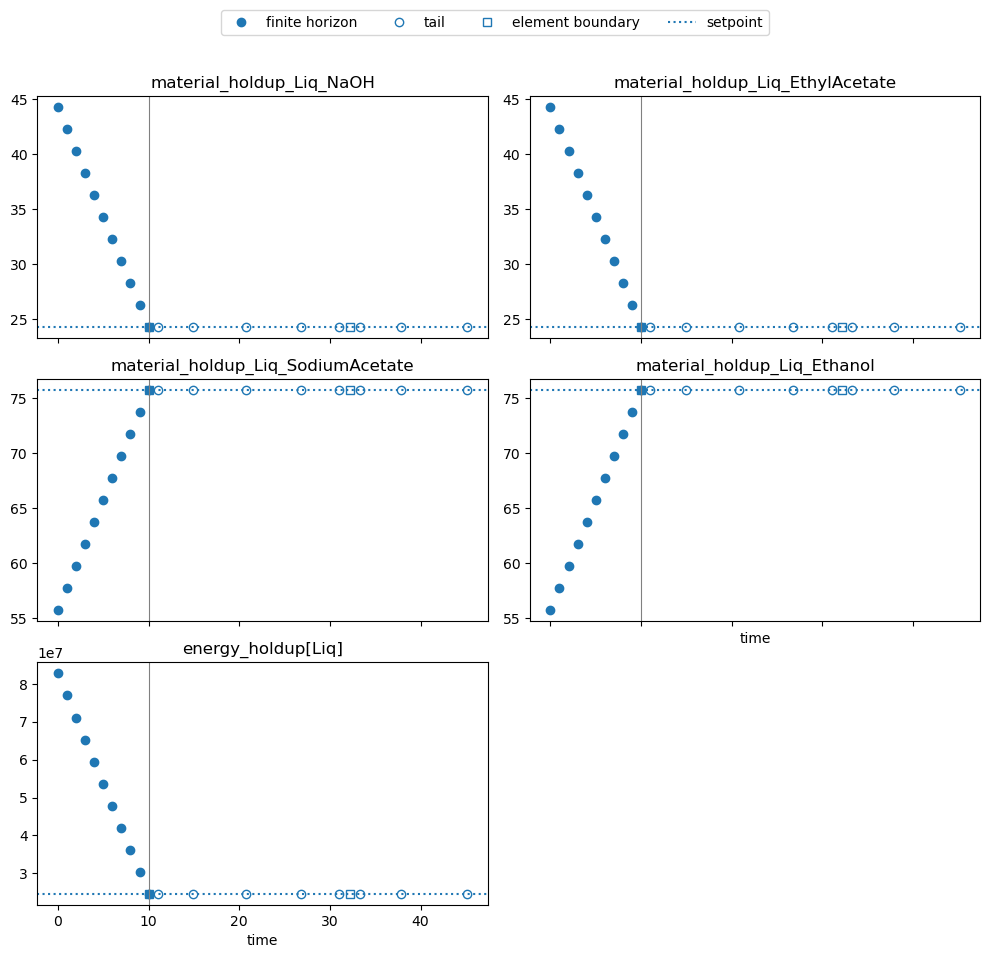

In [11]:
plot_states(m);
plt.show()

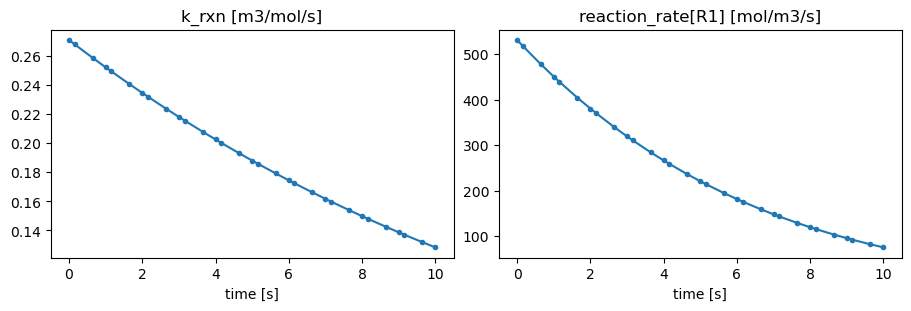

In [12]:
plot_rates(m)
plt.show()

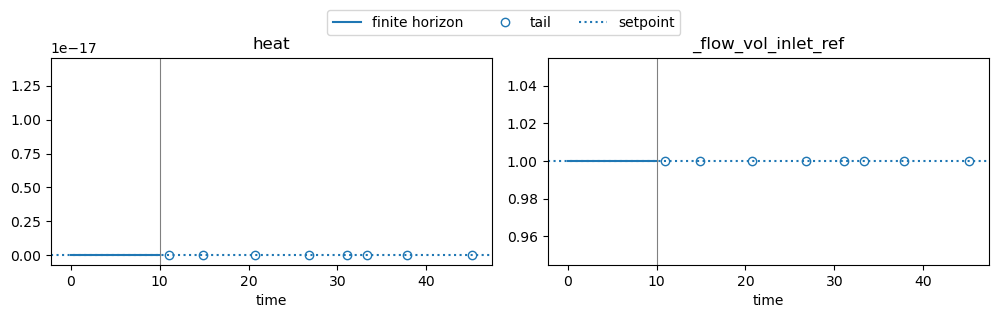

In [13]:
plot_controls(m);
plt.show()

## The first solve

The controller from the cold-started guess, through the scaled solve.
The log shows the iteration count from the linear start.

In [14]:
pyo.TransformationFactory("drto.dynamic_optimization").apply_to(m)
res = scaled_solve(m, tee=True)
print(res.solver.termination_condition)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpckj9mlrn.pyomo.nl...
Parsed 1409 vars,

pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmpckj9mlrn.pyomo.sol


  21  3.5488572e+03 1.14e-02 4.00e-02   -1.0 9.90e+07      - 9.92e-01 1.00e+00h  1
  22  3.5386359e+03 7.76e-02 1.30e-02   -1.7 7.61e+08      - 1.00e+00 1.00e+00f  1
  23  3.5376767e+03 5.12e-03 9.77e-04   -2.5 6.61e+08      - 1.00e+00 1.00e+00h  1
  24  3.5374672e+03 1.12e-04 2.06e-05   -3.8 2.14e+08      - 1.00e+00 1.00e+00h  1
  25  3.5374536e+03 3.24e-07 5.82e-08   -5.7 4.66e+07      - 1.00e+00 1.00e+00h  1
  26  3.5374534e+03 2.79e-09 7.87e-10   -8.6 2.12e-04   -5.4 1.00e+00 1.00e+00h  1


Number of Iterations....: 26

                                   (scaled)                 (unscaled)
Objective...............:   3.5374534385086417e+02    3.5374534385086413e+03
Dual infeasibility......:   7.8679302002501243e-10    7.8679302002501235e-09
Constraint violation....:   2.7939677238464355e-09    1.0058283805847168e-07
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5073801528380117e-09    2.5073801528380115e-08
Overall NLP er

optimal


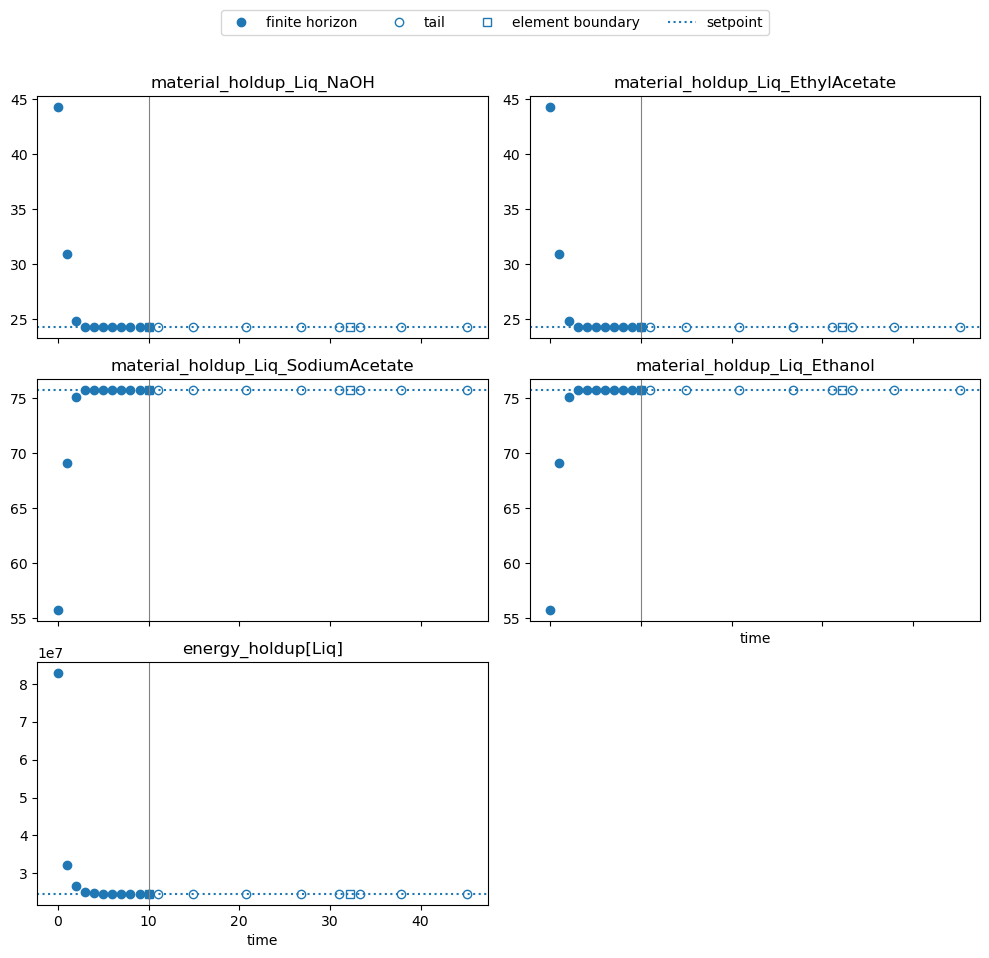

In [15]:
plot_states(m);
plt.show()

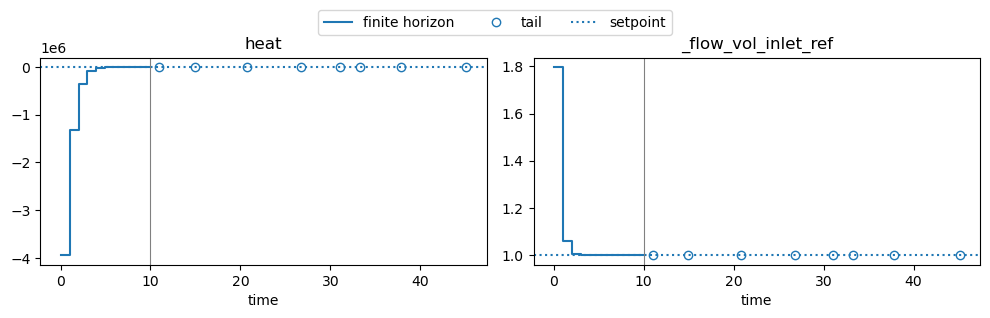

In [16]:
plot_controls(m);
plt.show()

## From scratch, with an exponential profile

The same model rebuilt and refilled, cold-started on the normalized
exponential decay instead of the line (time constant 3 s), and the same
solve again: compare the iteration count with the linear start above.

In [17]:
m2 = build()
for j, ssp in (("NaOH", m2.ss_naoh), ("EthylAcetate", m2.ss_ea),
               ("SodiumAcetate", m2.ss_sa), ("Ethanol", m2.ss_etoh)):
    ssp.set_value(pyo.value(cvs.material_holdup["Liq", j]))
for j, sgn in (("NaOH", 1), ("EthylAcetate", 1),
               ("SodiumAcetate", -1), ("Ethanol", -1)):
    m2.mat0[j] = pyo.value(cvs.material_holdup["Liq", j]) + sgn * DC_START * VOLUME
for k in m2.eng_ss:
    m2.eng_ss[k] = pyo.value(cvs.energy_holdup[k])
pyo.TransformationFactory("drto.infinite_horizon").apply_to(m2)

tag_scaling(m2)
print(drto.cold_start_dynamic(m2, profile="exponential", time_constant=3.0))

drto cold_start_dynamic (interpolate to the targets)
  states        : 5 on an exponential decay (time constant 3) across 31 grid points
  derivatives   : 155 at the profile's slope
  controls      : 2 at their targets
  segment       : 12 copies at the targets, slacks at zero
  point solves  : run (pyomo-pounce block solve, scaled clone)
  pyomo-pounce initialize (fill -> repair -> block-solve)
    decisions held: 342
    values filled : 0
    projection    : skipped
    pyomo-pounce block_initialize
      decisions fixed   : 0
      system square     : False
      blocks solved     : 1001 (1001 by Newton 1x1, 0 subsystem solves)
      vars initialized  : 1001
      left untouched    : 30 underdetermined, 0 overdetermined
      underconstrained vars (specify or flag as decisions): drto_ih.properties_out_flow_vol[0.015637], drto_ih.properties_out_flow_vol[0.076922], drto_ih.properties_out_flow_vol[0.166666], drto_ih.properties_out_flow_vol[0.256411], drto_ih.properties_out_flow_vol[0.3

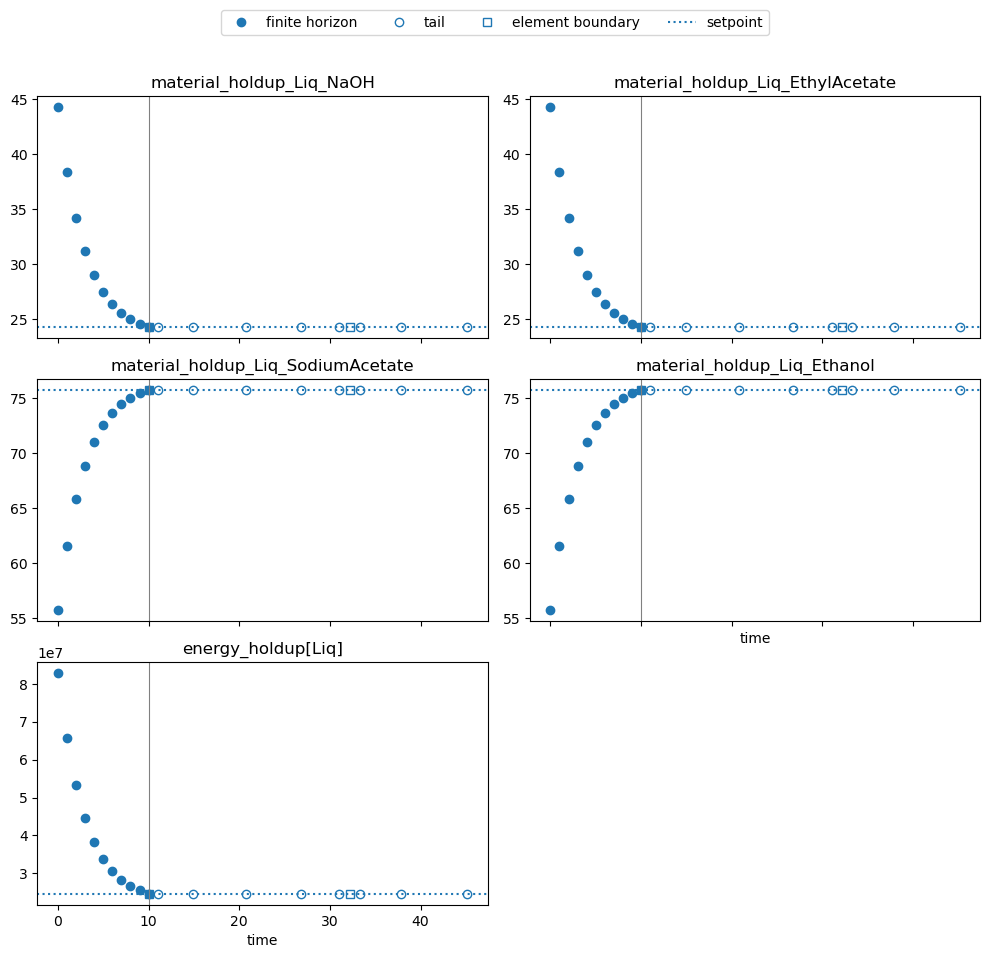

In [18]:
plot_states(m2)
plt.show()

In [19]:
pyo.TransformationFactory("drto.dynamic_optimization").apply_to(m2)
res = scaled_solve(m2, tee=True)
print(res.solver.termination_condition)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpfs5n65_j.pyomo.nl...
Parsed 1409 vars,

   9  3.5490568e+03 9.03e-05 8.39e-04   -1.0 1.06e+08      - 9.91e-01 1.00e+00f  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  10  3.5386356e+03 1.03e-01 1.30e-02   -1.7 7.54e+08      - 1.00e+00 1.00e+00f  1
  11  3.5376767e+03 7.12e-03 9.77e-04   -2.5 6.61e+08      - 1.00e+00 1.00e+00h  1
  12  3.5374672e+03 1.54e-04 2.06e-05   -3.8 2.14e+08      - 1.00e+00 1.00e+00h  1
  13  3.5374536e+03 4.43e-07 5.82e-08   -5.7 4.66e+07      - 1.00e+00 1.00e+00h  1
  14  3.5374534e+03 2.33e-09 8.53e-12   -8.6 5.10e+06      - 1.00e+00 1.00e+00h  1


Number of Iterations....: 14

                                   (scaled)                 (unscaled)
Objective...............:   3.5374534385086099e+02    3.5374534385086099e+03
Dual infeasibility......:   8.5272159342300591e-12    8.5272159342300591e-11
Constraint violation....:   2.3283064365386963e-09    4.0605664253234863e-07
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Compleme

optimal


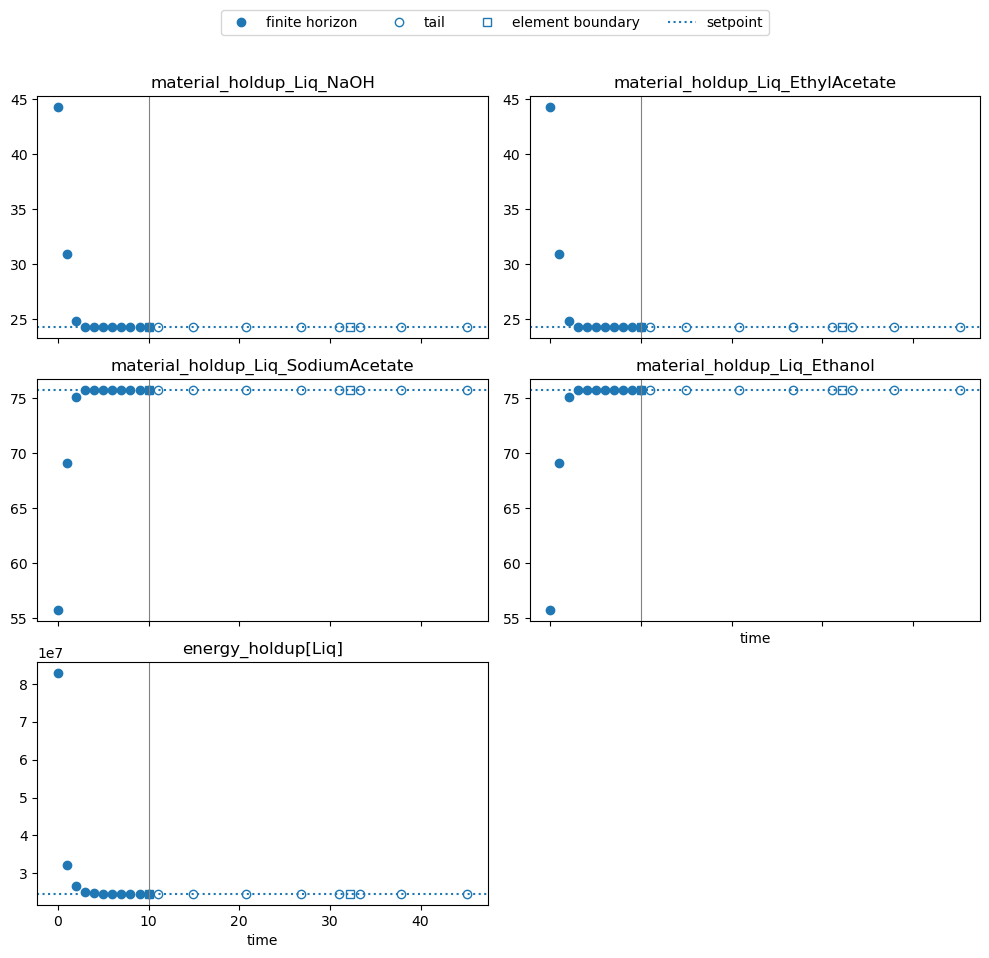

In [20]:
plot_states(m2);
plt.show()